# Diffusion Models and Flow Matching

Generative models learn to transform samples from a simple distribution, such as a standard Gaussian, into samples from a complicated data distribution.

This notebook builds two closely related approaches from scratch:

1. **Denoising diffusion** gradually corrupts data with Gaussian noise, then learns to reverse that corruption.
2. **Flow matching** learns a time-dependent velocity field that transports noise to data through an ordinary differential equation (ODE).

Both examples use an eight-mode 2D toy distribution. The low dimensional setting makes the trajectories visible while preserving the same objectives used in large image, audio, and video models.


In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


/home/yyf/miniconda3/envs/mmflow-vla/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Target distribution

The data distribution is a mixture of eight narrow Gaussians whose means lie on a circle. We sample it directly, so no dataset download is needed.


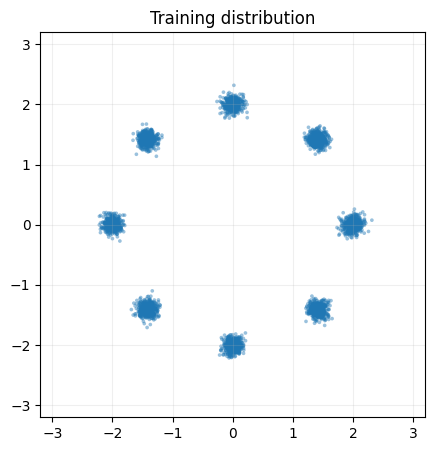

In [2]:
def sample_data(n, radius=2.0, std=0.08, device=device):
    """Sample n points from eight equally weighted Gaussian modes."""
    mode = torch.randint(0, 8, (n,), device=device)
    angle = 2 * math.pi * mode / 8
    centers = radius * torch.stack([angle.cos(), angle.sin()], dim=1)
    return centers + std * torch.randn(n, 2, device=device)


def scatter_samples(ax, samples, title, color="tab:blue"):
    points = samples.detach().cpu()
    ax.scatter(points[:, 0], points[:, 1], s=7, alpha=0.45, c=color, edgecolors="none")
    ax.set(title=title, xlim=(-3.2, 3.2), ylim=(-3.2, 3.2), aspect="equal")
    ax.grid(alpha=0.2)


fig, ax = plt.subplots(figsize=(5, 5))
scatter_samples(ax, sample_data(4_000), "Training distribution")
plt.show()


## 2. Time-conditioned neural network

Both models need a function of a point $x \in \mathbb{R}^2$ and time $t$. A sinusoidal embedding gives the MLP several time scales on which to represent its output:

$$
\operatorname{embed}(t)
=
[\sin(\omega_1 t), \cos(\omega_1 t), \ldots,
\sin(\omega_k t), \cos(\omega_k t)].
$$

The diffusion network predicts noise, $\epsilon_\theta(x_t,t)$. The flow network has the same architecture but predicts velocity, $v_\theta(x_t,t)$.


In [3]:
class FourierTimeEmbedding(nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        if dim % 2:
            raise ValueError("Embedding dimension must be even")
        frequencies = 2 ** torch.arange(dim // 2, dtype=torch.float32)
        self.register_buffer("frequencies", frequencies * math.pi)

    def forward(self, t):
        # t: [batch] in [0, 1]
        angles = t[:, None] * self.frequencies[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=1)


class TimeConditionedMLP(nn.Module):
    def __init__(self, hidden_dim=128, time_dim=32):
        super().__init__()
        self.time_embedding = FourierTimeEmbedding(time_dim)
        self.net = nn.Sequential(
            nn.Linear(2 + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_embedding(t)], dim=1))


def train_loop(model, loss_fn, steps=1_500, batch_size=512, lr=2e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    started = time.perf_counter()

    model.train()
    for step in range(1, steps + 1):
        loss = loss_fn(model, batch_size)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if step == 1 or step % 300 == 0:
            print(f"step {step:4d} | loss {np.mean(losses[-100:]):.4f}")

    elapsed = time.perf_counter() - started
    print(f"Finished in {elapsed:.1f}s")
    return losses


def plot_loss(losses, title):
    window = min(50, len(losses))
    smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
    plt.figure(figsize=(6, 3))
    plt.plot(smoothed)
    plt.xlabel("Training step")
    plt.ylabel("Moving-average MSE")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.show()


# Part I: Denoising Diffusion

## 3. Forward diffusion process

A denoising diffusion probabilistic model (DDPM) defines a fixed Markov chain that adds a small amount of Gaussian noise at every step:

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}\left(
    \sqrt{\alpha_t}\,x_{t-1},
    (1-\alpha_t)I
\right),
\qquad \alpha_t = 1-\beta_t.
$$

Let $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$. Because Gaussian transitions compose, any noise level can be sampled in one operation:

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I).
$$

As $t$ increases, the signal coefficient shrinks and $x_t$ approaches Gaussian noise. Training does not need to simulate all preceding steps.


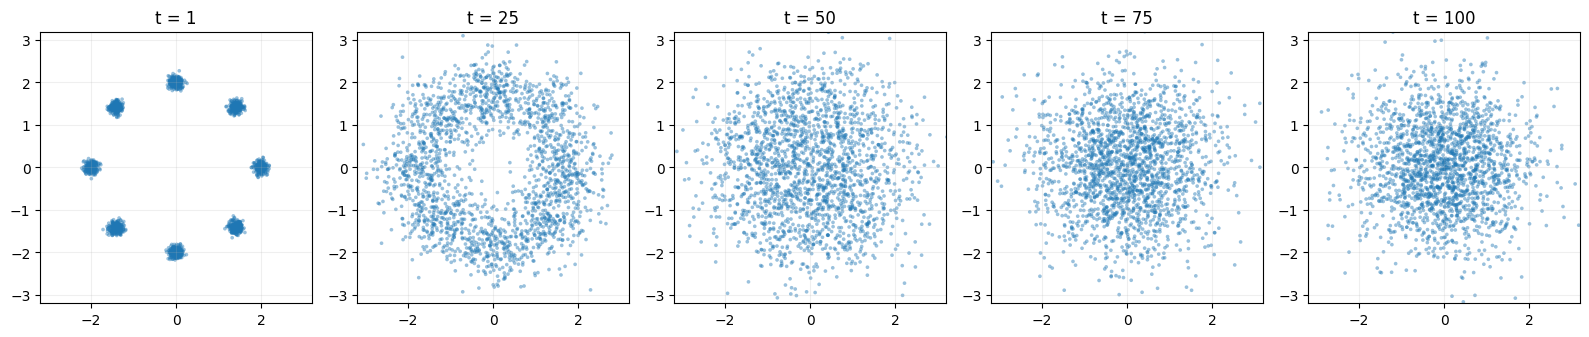

In [4]:
# A linear variance schedule for T discrete diffusion steps.
T = 100
# The larger endpoint compensates for using 100 rather than the usual
# 1,000 steps, making the final marginal close to standard Gaussian.
betas = torch.linspace(1e-4, 8e-2, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def extract(values, t):
    """Select one schedule value per batch item and reshape to [batch, 1]."""
    return values[t].unsqueeze(1)


def q_sample(x0, t, noise=None):
    """Draw x_t directly from q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x0)
    signal = extract(alpha_bars.sqrt(), t)
    noise_scale = extract((1.0 - alpha_bars).sqrt(), t)
    return signal * x0 + noise_scale * noise, noise


x0 = sample_data(2_000)
snapshots = []
for step in [0, 24, 49, 74, 99]:
    t = torch.full((len(x0),), step, device=device, dtype=torch.long)
    xt, _ = q_sample(x0, t)
    snapshots.append((step + 1, xt))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, (step, xt) in zip(axes, snapshots):
    scatter_samples(ax, xt, f"t = {step}")
plt.tight_layout()
plt.show()


## 4. Noise-prediction objective

We create a supervised example by sampling $x_0$, a time index $t$, and noise $\epsilon$, then constructing $x_t$ with the closed-form equation above. The network minimizes

$$
\mathcal{L}_{\text{simple}}
=
\mathbb{E}_{x_0,t,\epsilon}
\left[
\left\|
\epsilon -
\epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

Predicting the added noise is equivalent, up to time-dependent scaling, to learning the score $\nabla_{x_t}\log q_t(x_t)$. It also gives the reverse process an estimate of the clean-data direction.


step    1 | loss 0.9554
step  300 | loss 0.5008
step  600 | loss 0.4121
step  900 | loss 0.4006
step 1200 | loss 0.3751
step 1500 | loss 0.3597
Finished in 2.9s


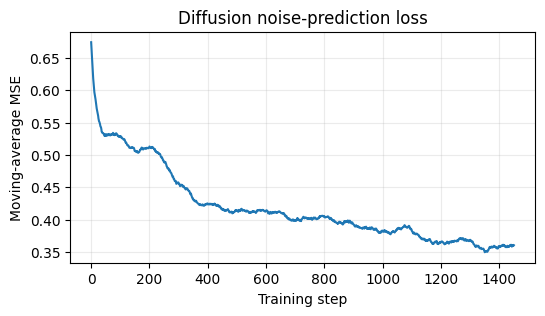

In [5]:
def diffusion_loss(model, batch_size):
    x0 = sample_data(batch_size)
    t = torch.randint(0, T, (batch_size,), device=device)
    xt, noise = q_sample(x0, t)
    t_normalized = t.float() / (T - 1)
    predicted_noise = model(xt, t_normalized)
    return F.mse_loss(predicted_noise, noise)


diffusion_model = TimeConditionedMLP().to(device)
diffusion_losses = train_loop(diffusion_model, diffusion_loss)
plot_loss(diffusion_losses, "Diffusion noise-prediction loss")


## 5. Reverse diffusion sampler

Sampling begins with $x_T \sim \mathcal{N}(0,I)$ and repeatedly estimates $x_{t-1}$. With a noise-prediction model, the DDPM reverse mean is

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
    x_t
    -
    \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
    \epsilon_\theta(x_t,t)
\right).
$$

For $t>1$, sample around this mean using the posterior variance

$$
\tilde{\beta}_t
=
\beta_t
\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}.
$$

This implementation stores a few intermediate states so we can inspect how initially unstructured noise separates into modes.


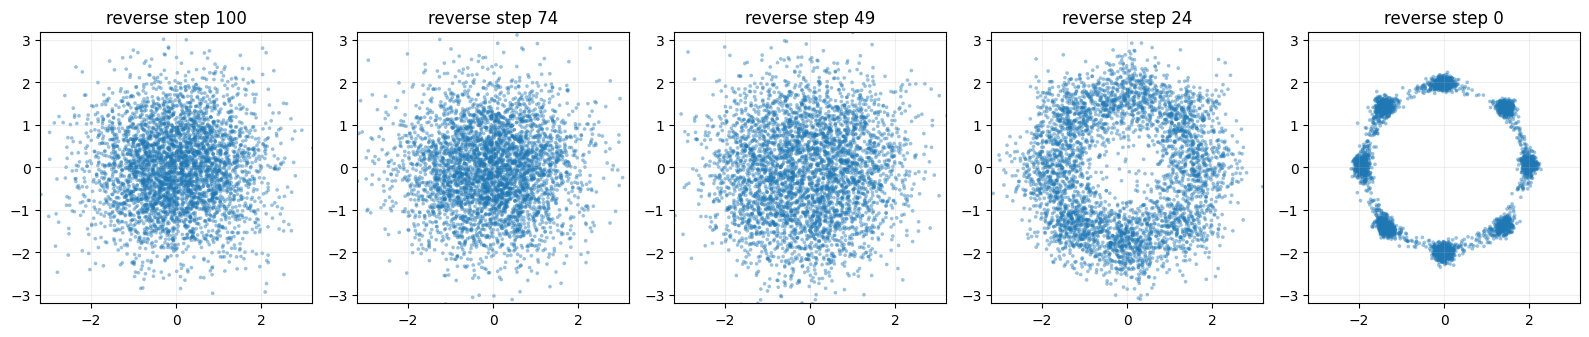

In [6]:
@torch.no_grad()
def sample_diffusion(model, n=4_000, keep_steps=(99, 74, 49, 24, 0)):
    model.eval()
    x = torch.randn(n, 2, device=device)
    trajectory = {T: x.detach().cpu()}

    for step in reversed(range(T)):
        t = torch.full((n,), step, device=device, dtype=torch.long)
        t_normalized = t.float() / (T - 1)
        predicted_noise = model(x, t_normalized)

        beta_t = betas[step]
        alpha_t = alphas[step]
        alpha_bar_t = alpha_bars[step]
        mean = (x - beta_t / torch.sqrt(1 - alpha_bar_t) * predicted_noise)
        mean = mean / torch.sqrt(alpha_t)

        if step > 0:
            alpha_bar_previous = alpha_bars[step - 1]
            posterior_variance = beta_t * (1 - alpha_bar_previous) / (1 - alpha_bar_t)
            x = mean + posterior_variance.sqrt() * torch.randn_like(x)
        else:
            x = mean

        if step in keep_steps:
            trajectory[step] = x.detach().cpu()

    return x, trajectory


diffusion_samples, diffusion_trajectory = sample_diffusion(diffusion_model)

display_steps = [100, 74, 49, 24, 0]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, step in zip(axes, display_steps):
    scatter_samples(ax, diffusion_trajectory[step], f"reverse step {step}")
plt.tight_layout()
plt.show()


### Diffusion result

A useful sanity check is whether generated points cover all modes without filling the low-density space between them. Because this is a tiny model trained briefly, the match will not be perfect, but the learned distribution should clearly recover the ring structure.


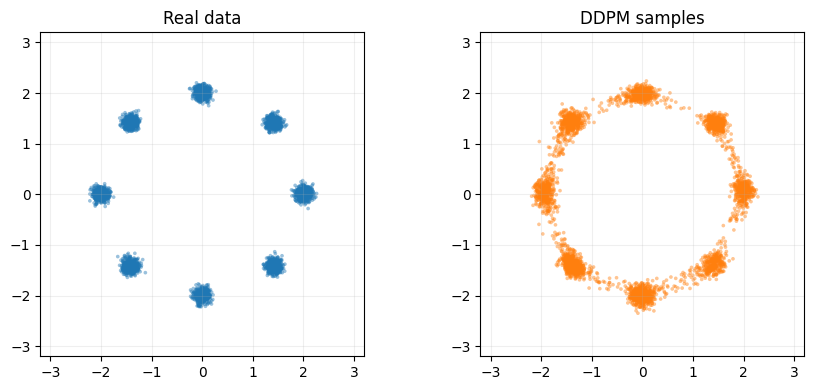

In [7]:
real_samples = sample_data(4_000)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_samples(axes[0], real_samples, "Real data")
scatter_samples(axes[1], diffusion_samples, "DDPM samples", color="tab:orange")
plt.tight_layout()
plt.show()


# Part II: Flow Matching

## 6. From stochastic noising to deterministic transport

Flow matching learns a continuous-time vector field $v_\theta(x,t)$. Samples evolve according to the ODE

$$
\frac{d x_t}{dt} = v_\theta(x_t,t),
\qquad x_0 \sim p_0,
$$

where $p_0$ is an easy source distribution and the flow should satisfy $x_1 \sim p_{\text{data}}$.

For **conditional flow matching**, pair a noise point $x_0 \sim \mathcal{N}(0,I)$ with a data point $x_1 \sim p_{\text{data}}$ and choose the straight interpolation

$$
x_t = (1-t)x_0 + tx_1.
$$

Its conditional target velocity is available analytically:

$$
u_t(x_t \mid x_0,x_1)
=
\frac{d x_t}{dt}
=
x_1-x_0.
$$

The regression objective is therefore

$$
\mathcal{L}_{\text{FM}}
=
\mathbb{E}_{x_0,x_1,t}
\left[
\left\|
v_\theta(x_t,t)-(x_1-x_0)
\right\|_2^2
\right].
$$

Although individual training pairs use straight lines, the model only observes $(x_t,t)$, not the endpoints. Averaging compatible conditional velocities produces a generally curved marginal flow field.


step    1 | loss 2.9127
step  300 | loss 2.0200
step  600 | loss 1.9330
step  900 | loss 1.8604
step 1200 | loss 1.8132
step 1500 | loss 1.8111
Finished in 1.5s


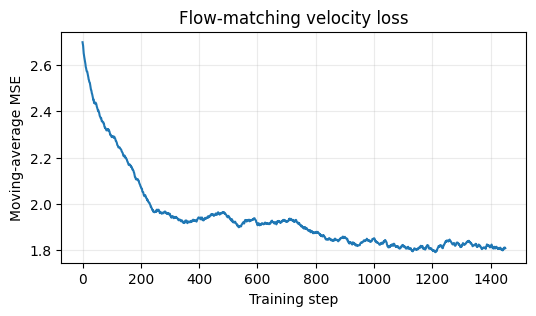

In [8]:
def flow_matching_loss(model, batch_size):
    x0 = torch.randn(batch_size, 2, device=device)
    x1 = sample_data(batch_size)
    t = torch.rand(batch_size, device=device)

    xt = (1 - t[:, None]) * x0 + t[:, None] * x1
    target_velocity = x1 - x0
    predicted_velocity = model(xt, t)
    return F.mse_loss(predicted_velocity, target_velocity)


flow_model = TimeConditionedMLP().to(device)
flow_losses = train_loop(flow_model, flow_matching_loss)
plot_loss(flow_losses, "Flow-matching velocity loss")


## 7. ODE sampling

Once the velocity field is trained, solve the ODE from $t=0$ to $t=1$. The simplest numerical solver is forward Euler:

$$
x_{t+\Delta t}
=
x_t + \Delta t\,v_\theta(x_t,t).
$$

Unlike ancestral DDPM sampling, this trajectory is deterministic after drawing the initial noise. Better solvers such as midpoint, Heun, or adaptive Runge-Kutta can achieve higher accuracy with fewer network evaluations.


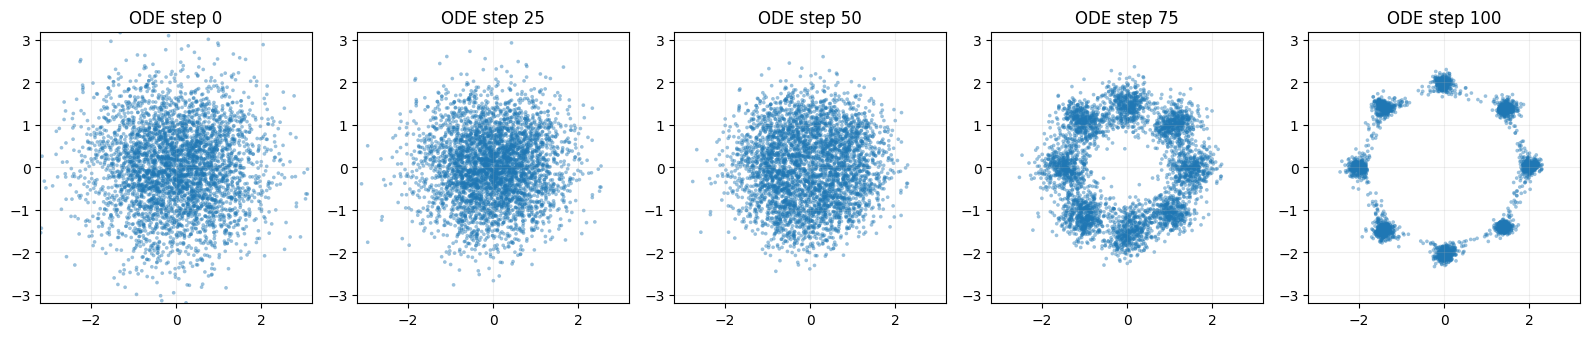

In [9]:
@torch.no_grad()
def sample_flow(model, n=4_000, n_steps=100, keep_steps=(0, 25, 50, 75, 100)):
    model.eval()
    x = torch.randn(n, 2, device=device)
    trajectory = {0: x.detach().cpu()}
    dt = 1.0 / n_steps

    for step in range(n_steps):
        t = torch.full((n,), step / n_steps, device=device)
        velocity = model(x, t)
        x = x + dt * velocity

        if step + 1 in keep_steps:
            trajectory[step + 1] = x.detach().cpu()

    return x, trajectory


flow_samples, flow_trajectory = sample_flow(flow_model)

display_steps = [0, 25, 50, 75, 100]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, step in zip(axes, display_steps):
    scatter_samples(ax, flow_trajectory[step], f"ODE step {step}")
plt.tight_layout()
plt.show()


## 8. Side-by-side comparison

| Property | Denoising diffusion (DDPM here) | Flow matching |
|---|---|---|
| Learned quantity | Added noise / score | Velocity field |
| Training state | Noisy data from a variance schedule | Interpolation between source and data |
| Generation | Reverse stochastic Markov chain | Numerical integration of an ODE |
| Path | Usually stochastic | Deterministic given initial noise |
| Discretization knob | Number and schedule of denoising steps | ODE solver and number of function evaluations |
| Common failure from too few steps | Denoising error and artifacts | ODE integration error |

The methods are more closely related than the table might suggest. Both learn a time-indexed vector field that points noisy/intermediate samples toward higher-probability data configurations. Diffusion can also be expressed through a deterministic **probability-flow ODE**, while flow-matching paths can be generalized beyond the straight interpolation used here.


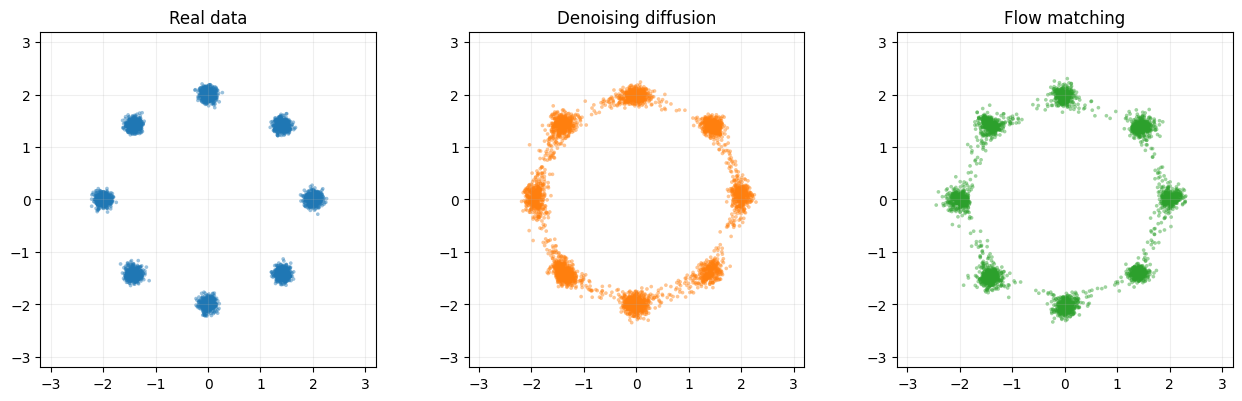

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
scatter_samples(axes[0], real_samples, "Real data")
scatter_samples(axes[1], diffusion_samples, "Denoising diffusion", color="tab:orange")
scatter_samples(axes[2], flow_samples, "Flow matching", color="tab:green")
plt.tight_layout()
plt.show()


## 9. Practical extensions

The minimal implementations above expose the essential algorithms. Production models commonly add:

- **Architecture:** replace the MLP with a U-Net or diffusion transformer for spatial data.
- **Conditioning:** inject class labels, text embeddings, or other context; classifier-free guidance combines conditional and unconditional predictions.
- **Diffusion parameterization:** predict noise $\epsilon$, clean data $x_0$, or velocity $v$; use cosine or learned noise schedules.
- **Faster sampling:** use DDIM, higher-order diffusion solvers, consistency distillation, or fewer-step latent-space models.
- **Flow paths:** use variance-preserving, optimal-transport-inspired, or stochastic interpolants rather than independent straight-line pairs.
- **ODE solvers:** trade function evaluations for accuracy with midpoint, Heun, Runge-Kutta, or adaptive solvers.

### Core takeaway

Diffusion learns to undo a known corruption process. Flow matching directly learns how probability mass should move. Their training targets differ, but both turn simple noise into structured data by learning dynamics over time.
